### CELL 1: GothamDataset2025 Exploration

Found 78 CSV files in GothamDataset2025/processed


Reading CSVs: 100%|██████████| 78/78 [02:43<00:00,  2.10s/it]



Total rows read: 35134281
Columns: ['frame.time', 'frame.len', 'frame.protocols', 'eth.src', 'eth.dst', 'ip.dst', 'ip.src', 'ip.flags', 'ip.ttl', 'ip.proto', 'ip.checksum', 'ip.tos', 'tcp.srcport', 'tcp.dstport', 'tcp.flags', 'tcp.window_size_value', 'tcp.window_size_scalefactor', 'tcp.checksum', 'tcp.options', 'tcp.pdu.size', 'udp.srcport', 'udp.dstport', 'label', 'source_file']

No missing values in critical columns.
Filled missing values in 'tcp.srcport' with 0.
Filled missing values in 'tcp.dstport' with 0.
Filled missing values in 'udp.srcport' with 0.
Filled missing values in 'udp.dstport' with 0.

Created 'window_start' column (rounded to 60s intervals).

--- Label distribution (raw) ---
label
Benign                      12256883
Mirai UDP Flooding           8897895
Mirai TCP Flooding           6548173
Mirai GRE Flooding           5911401
TCP Scan                      737764
CoAP Amplification            274837
Telnet Brute Force            227649
Merlin TCP Flooding           

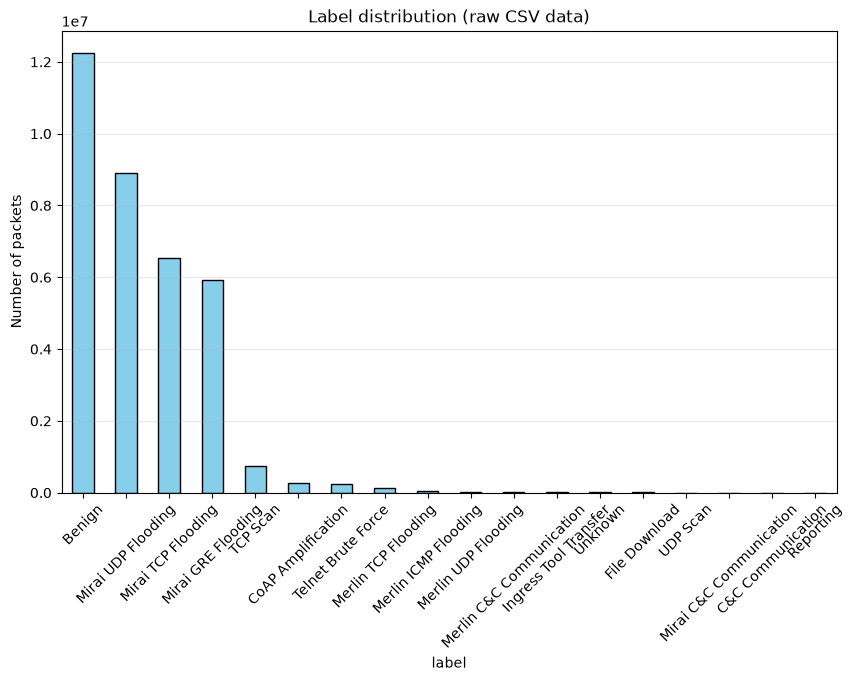


Protocol distribution (ip.proto):
ip.proto
1        82404
6      8481367
17    20659109
47     5911401
Name: count, dtype: int64


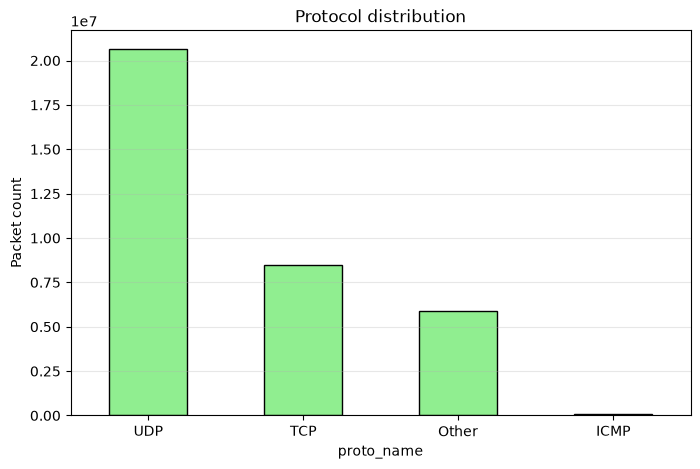


Timestamp range:
  Start: 2025-01-14 18:39:55.330053
  End:   2025-01-25 19:46:06.049464


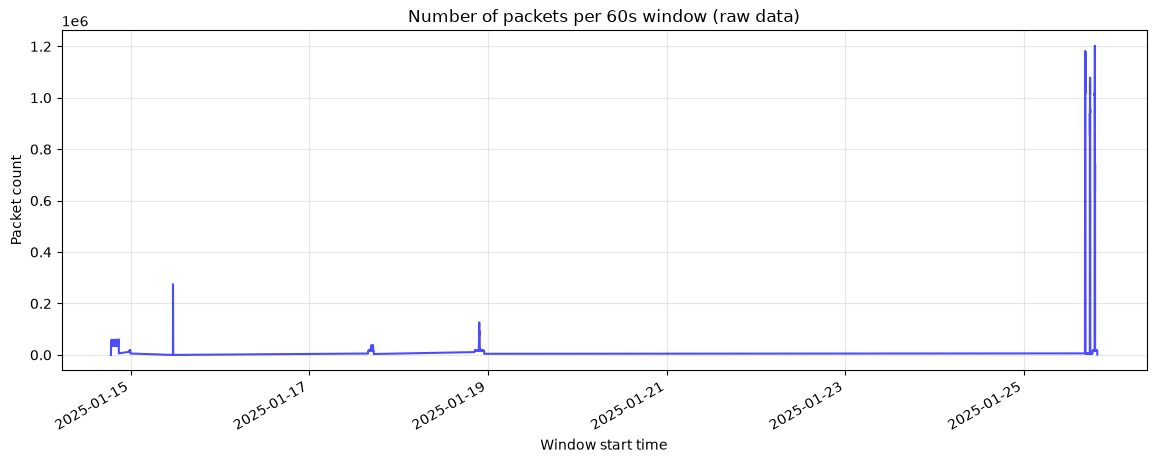


First 5 windows (start time -> packet count):
window_start
2025-01-14 18:39:00       24
2025-01-14 18:40:00    39206
2025-01-14 18:41:00    40535
2025-01-14 18:42:00    48625
2025-01-14 18:43:00    52191
dtype: int64

--- Attack counts per window (first 5 windows) ---
label                Benign  C&C Communication  CoAP Amplification  \
window_start                                                         
2025-01-14 18:39:00      24                  0                   0   
2025-01-14 18:40:00   39206                  0                   0   
2025-01-14 18:41:00   40535                  0                   0   
2025-01-14 18:42:00   48625                  0                   0   
2025-01-14 18:43:00   52191                  0                   0   

label                File Download  Ingress Tool Transfer  \
window_start                                                
2025-01-14 18:39:00              0                      0   
2025-01-14 18:40:00              0                      

<Figure size 1400x600 with 0 Axes>

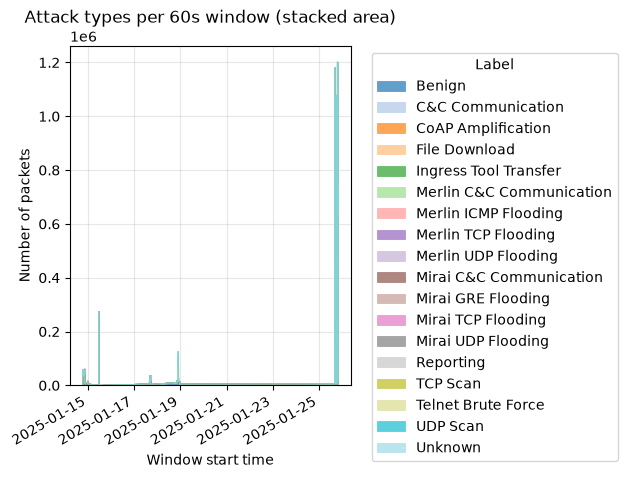

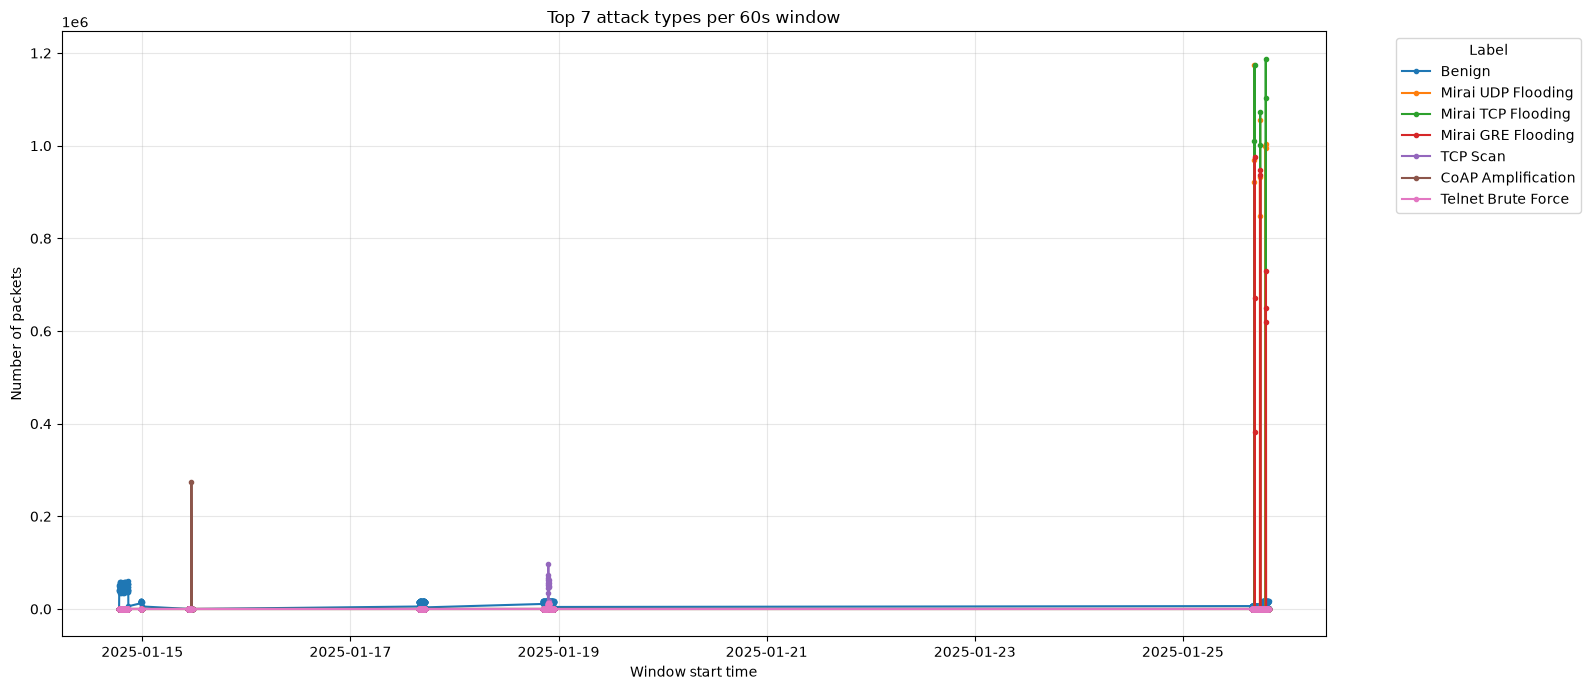

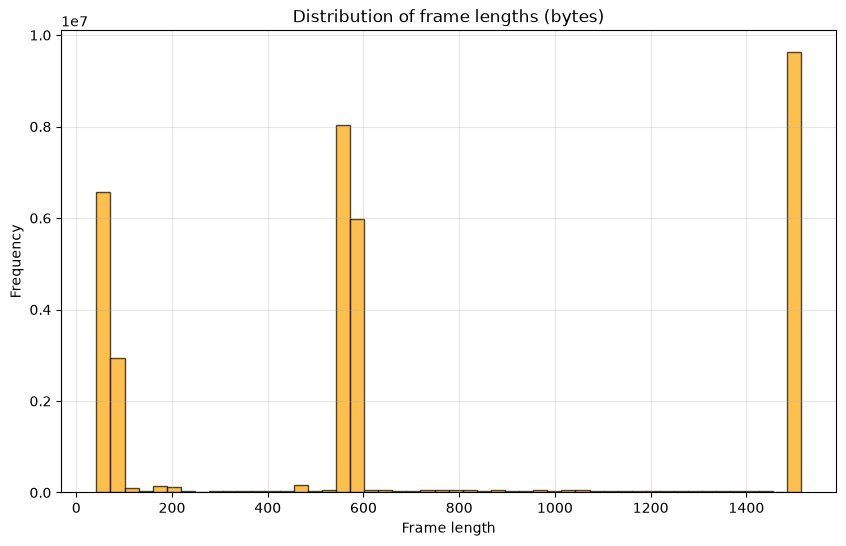


Frame length statistics:
count    3.513428e+07
mean     6.995942e+02
std      5.533963e+02
min      4.200000e+01
25%      7.400000e+01
50%      5.660000e+02
75%      1.514000e+03
max      1.514000e+03
Name: frame.len, dtype: float64

Negative frame.len: 0

--- Packet counts per source file ---
source_file
iotsim-ip-camera-museum-1    10447197
iotsim-combined-cycle-1       5974887
iotsim-building-monitor-1     5550987
iotsim-ip-camera-street-1     5469337
iotsim-domotic-monitor-1      2114866
                               ...   
iotsim-combined-cycle-4           254
iotsim-combined-cycle-5           254
iotsim-combined-cycle-6           254
iotsim-combined-cycle-7           254
iotsim-combined-cycle-8           254
Name: count, Length: 78, dtype: int64


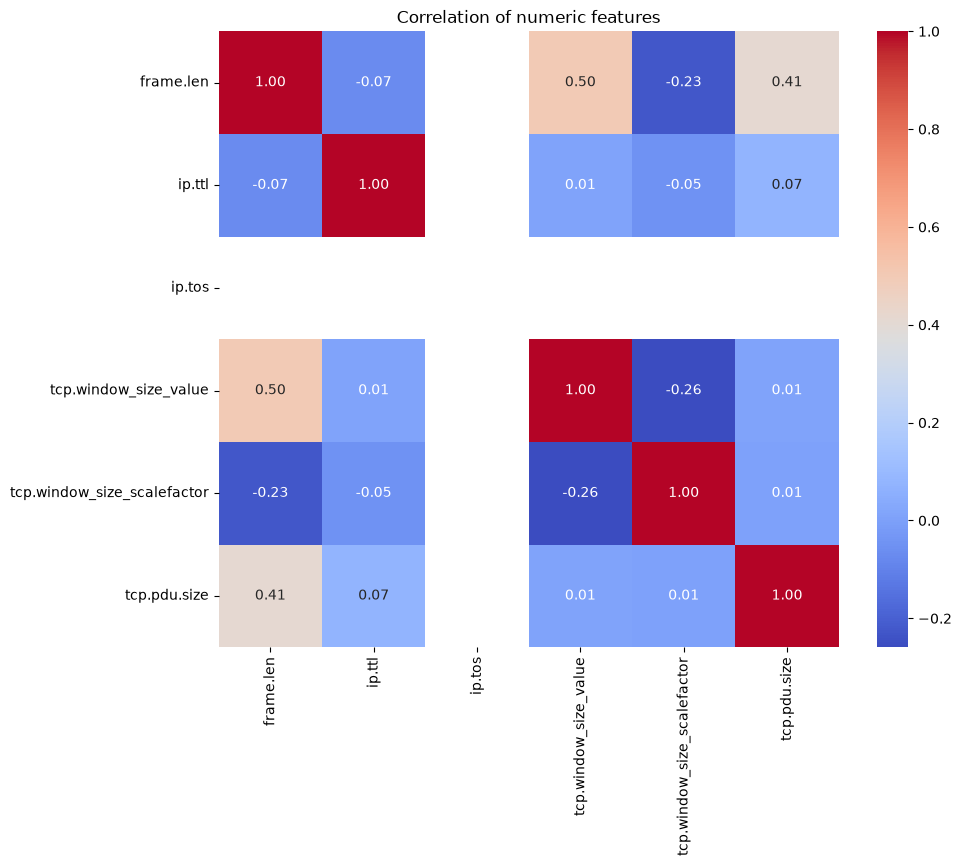


--- Protocol vs Label (packet counts) ---
label         Benign  C&C Communication  CoAP Amplification  File Download  \
proto_name                                                                   
UDP         11454647                  0              274837              0   
TCP           790004                528                   0           7196   
Other              0                  0                   0              0   
ICMP           12232                  0                   0              0   

label       Ingress Tool Transfer  Merlin C&C Communication  \
proto_name                                                    
UDP                             0                         0   
TCP                         21587                     29356   
Other                           0                         0   
ICMP                            0                         0   

label       Merlin ICMP Flooding  Merlin TCP Flooding  Merlin UDP Flooding  \
proto_name                     

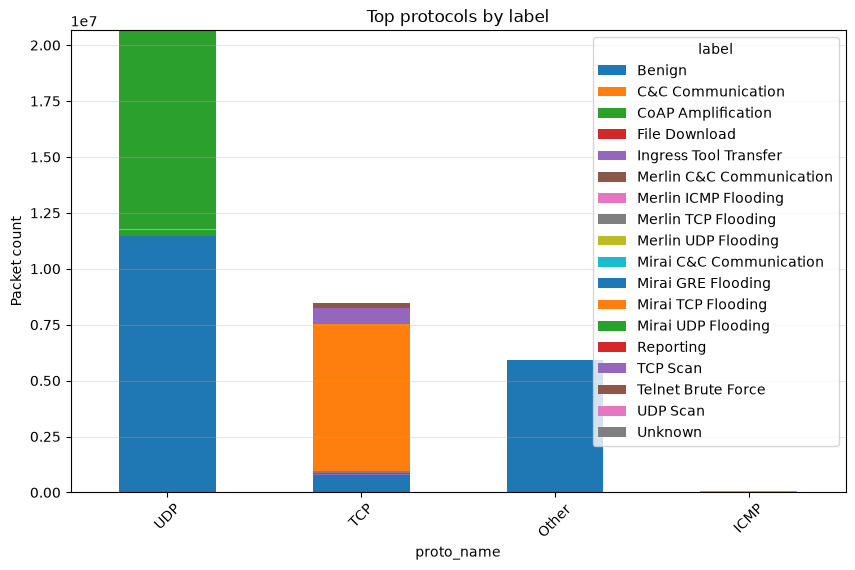


--- Additional network stats ---
Unique source IPs: 108
Unique destination IPs: 4116
Unique pairs (src,dst): 20178

Flows per window (sample of 100 windows):
count       100.00000
mean     120730.00000
std      265092.85034
min           3.00000
25%         848.75000
50%         925.50000
75%       13893.50000
max      912164.00000
Name: flow_key, dtype: float64

Saved combined raw data (with window_start) to 'combined_raw_with_windows.parquet'

Validation and exploration complete. Data looks consistent.
You can now build snapshots using 'window_start' with 60s windows.


In [1]:
# Full Gotham exploration (matches your notebook)
import os, glob, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

DATA_DIR = "GothamDataset2025/processed"
WINDOW_SECONDS = 60

csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print(f"Found {len(csv_files)} CSV files in {DATA_DIR}")

dtype_spec = {'tcp.flags': str, 'tcp.checksum': str, 'tcp.options': str}
all_dfs = []
for fpath in tqdm(csv_files, desc="Reading CSVs"):
    df = pd.read_csv(fpath, parse_dates=['frame.time'], dtype=dtype_spec, low_memory=False)
    df['source_file'] = Path(fpath).stem
    all_dfs.append(df)

df_all = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal rows read: {len(df_all)}")
print("Columns:", df_all.columns.tolist())

# Missing values
critical_cols = ['frame.time', 'ip.src', 'ip.dst', 'label', 'ip.proto', 'frame.len']
missing_critical = df_all[critical_cols].isnull().sum()
if missing_critical.any():
    print("\nWarning: missing values in critical columns:")
    print(missing_critical[missing_critical > 0])
else:
    print("\nNo missing values in critical columns.")

# Fill ports
port_cols = ['tcp.srcport','tcp.dstport','udp.srcport','udp.dstport']
for col in port_cols:
    if col in df_all.columns:
        df_all[col] = df_all[col].fillna(0).astype(int)
        print(f"Filled missing values in '{col}' with 0.")

# Window start
df_all['window_start'] = df_all['frame.time'].dt.floor(f'{WINDOW_SECONDS}s')
print(f"\nCreated 'window_start' column (rounded to {WINDOW_SECONDS}s intervals).")

# Label distribution
if 'label' in df_all.columns:
    print("\n--- Label distribution (raw) ---")
    label_counts = df_all['label'].value_counts(dropna=False)
    print(label_counts)
    plt.figure(figsize=(10,6))
    label_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Label distribution (raw CSV data)')
    plt.ylabel('Number of packets')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Protocol distribution
if 'ip.proto' in df_all.columns:
    proto_counts = df_all['ip.proto'].value_counts().sort_index()
    print("\nProtocol distribution (ip.proto):")
    print(proto_counts)
    proto_names = {6:'TCP', 17:'UDP', 1:'ICMP', 2:'IGMP', 89:'OSPF'}
    df_all['proto_name'] = df_all['ip.proto'].map(proto_names).fillna('Other')
    plt.figure(figsize=(8,5))
    df_all['proto_name'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
    plt.title('Protocol distribution')
    plt.ylabel('Packet count')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Timestamp range and traffic volume
if 'frame.time' in df_all.columns:
    print(f"\nTimestamp range:")
    print(f"  Start: {df_all['frame.time'].min()}")
    print(f"  End:   {df_all['frame.time'].max()}")
    window_counts = df_all.groupby('window_start').size()
    plt.figure(figsize=(14,5))
    window_counts.plot(kind='line', color='blue', alpha=0.7)
    plt.title(f'Number of packets per {WINDOW_SECONDS}s window (raw data)')
    plt.xlabel('Window start time')
    plt.ylabel('Packet count')
    plt.grid(alpha=0.3)
    plt.show()
    print("\nFirst 5 windows (start time -> packet count):")
    print(window_counts.head())

# Attack distribution over time (stacked area and line)
if 'label' in df_all.columns and 'window_start' in df_all.columns:
    attack_over_time = df_all.groupby(['window_start', 'label']).size().unstack(fill_value=0)
    print("\n--- Attack counts per window (first 5 windows) ---")
    print(attack_over_time.head())
    
    # Stacked area
    plt.figure(figsize=(14,6))
    attack_over_time.plot.area(stacked=True, alpha=0.7, colormap='tab20', linewidth=0.5)
    plt.title(f'Attack types per {WINDOW_SECONDS}s window (stacked area)')
    plt.xlabel('Window start time')
    plt.ylabel('Number of packets')
    plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Line chart (top 7)
    total_counts = attack_over_time.sum().sort_values(ascending=False)
    TOP_N = 7
    top_labels = total_counts.head(TOP_N).index
    attack_top = attack_over_time[top_labels]
    plt.figure(figsize=(16,7))
    for col in attack_top.columns:
        plt.plot(attack_top.index, attack_top[col], marker='o', markersize=3, linewidth=1.5, label=col)
    plt.title(f'Top {TOP_N} attack types per {WINDOW_SECONDS}s window')
    plt.xlabel('Window start time')
    plt.ylabel('Number of packets')
    plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('top_attacks_line_chart.png', dpi=300, bbox_inches='tight')
    plt.show()

# Frame length distribution
if 'frame.len' in df_all.columns:
    plt.figure(figsize=(10,6))
    df_all['frame.len'].hist(bins=50, color='orange', alpha=0.7, edgecolor='black')
    plt.title('Distribution of frame lengths (bytes)')
    plt.xlabel('Frame length')
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.show()
    print("\nFrame length statistics:")
    print(df_all['frame.len'].describe())

# Sanity checks
if 'frame.len' in df_all.columns:
    neg_len = (df_all['frame.len'] < 0).sum()
    print(f"\nNegative frame.len: {neg_len}")
for col in port_cols:
    if col in df_all.columns:
        max_val = df_all[col].max()
        if max_val > 65535:
            print(f"Warning: {col} has values > 65535 (max={max_val})")

# Per-file packet counts
print("\n--- Packet counts per source file ---")
file_counts = df_all['source_file'].value_counts()
print(file_counts)

# Correlation heatmap
numeric_cols = ['frame.len', 'ip.ttl', 'ip.tos', 
                'tcp.window_size_value', 'tcp.window_size_scalefactor', 'tcp.pdu.size']
numeric_cols = [c for c in numeric_cols if c in df_all.columns]
if numeric_cols:
    plt.figure(figsize=(10,8))
    corr = df_all[numeric_cols].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation of numeric features')
    plt.show()

# Protocol vs Label cross-tab
if 'proto_name' in df_all.columns and 'label' in df_all.columns:
    print("\n--- Protocol vs Label (packet counts) ---")
    top_protos = df_all['proto_name'].value_counts().head(5).index
    prot_label = pd.crosstab(df_all['proto_name'], df_all['label'])
    print(prot_label.loc[top_protos])
    prot_label.loc[top_protos].plot(kind='bar', stacked=True, figsize=(10,6))
    plt.title('Top protocols by label')
    plt.ylabel('Packet count')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Additional stats: unique IPs and flows per window (sample)
print("\n--- Additional network stats ---")
print(f"Unique source IPs: {df_all['ip.src'].nunique()}")
print(f"Unique destination IPs: {df_all['ip.dst'].nunique()}")
print(f"Unique pairs (src,dst): {df_all.groupby(['ip.src','ip.dst']).ngroups}")

# Flows per window (sample 100 windows)
sample_windows = df_all['window_start'].value_counts().head(100).index
df_sample = df_all[df_all['window_start'].isin(sample_windows)]
def get_flow_key(row):
    sport = row.get('tcp.srcport', 0) if row.get('tcp.srcport', 0) != 0 else row.get('udp.srcport', 0)
    dport = row.get('tcp.dstport', 0) if row.get('tcp.dstport', 0) != 0 else row.get('udp.dstport', 0)
    return (row['ip.src'], row['ip.dst'], row['ip.proto'], sport, dport)
df_sample['flow_key'] = df_sample.apply(get_flow_key, axis=1)
flows_per_window = df_sample.groupby('window_start')['flow_key'].nunique()
print("\nFlows per window (sample of 100 windows):")
print(flows_per_window.describe())

# Save cleaned data
df_all.to_parquet('combined_raw_with_windows.parquet', index=False)
print("\nSaved combined raw data (with window_start) to 'combined_raw_with_windows.parquet'")

print("\nValidation and exploration complete. Data looks consistent.")
print(f"You can now build snapshots using 'window_start' with {WINDOW_SECONDS}s windows.")

### CELL 2: MQTTEEB‑D Exploration


Loaded 634644 rows, 13 columns.
Columns: ['timestamp', 'tcp_flags', 'tcp_time_delta', 'tcp_len', 'mqtt_conack_flags', 'mqtt_conflag_cleansess', 'mqtt_conflags', 'mqtt_dupflag', 'mqtt_hdrflags', 'mqtt_kalive', 'mqtt_msg', 'mqtt_qos', 'Target']

Sample rows:
                      timestamp  tcp_flags  tcp_time_delta  tcp_len  \
0 2024-09-09 03:17:53.839302912   0.888889    1.725852e+09      617   
1 2024-09-09 03:18:04.324335104   0.888889    1.725852e+09      609   
2 2024-09-09 03:18:14.806340864   0.888889    1.725852e+09      614   
3 2024-09-09 03:18:25.294880000   0.888889    1.725852e+09      615   
4 2024-09-09 03:18:35.780612096   0.888889    1.725852e+09      615   

   mqtt_conack_flags  mqtt_conflag_cleansess  mqtt_conflags  mqtt_dupflag  \
0                  0                     0.0              0           0.0   
1                  0                     0.0              0           0.0   
2                  0                     0.0              0           0.0   
3       

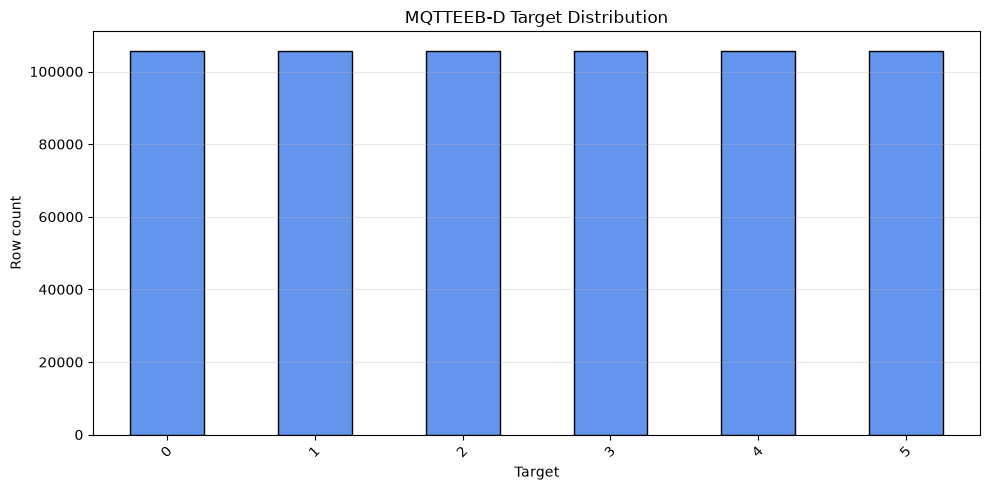


--- Target counts per window (first 5) ---
Target               0     1  2   3  4  5
window_start                             
2024-09-09 03:17:00  0     0  0   1  0  0
2024-09-09 03:18:00  0     0  0  51  0  0
2024-09-09 03:19:00  0  2701  0  15  0  0
2024-09-09 03:20:00  0   563  0  19  0  0
2024-09-09 03:21:00  0  1113  0  25  0  0


<Figure size 1400x600 with 0 Axes>

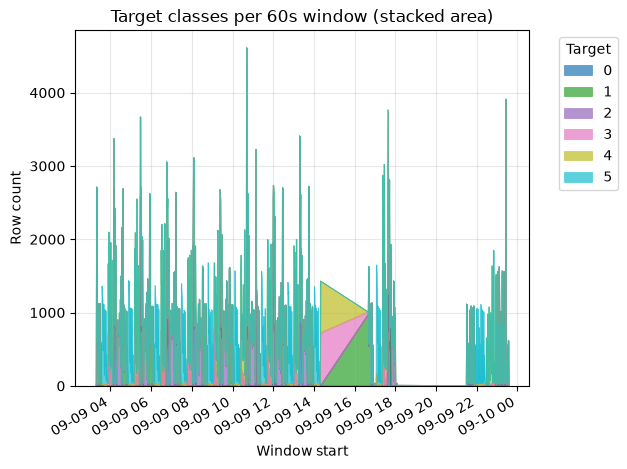

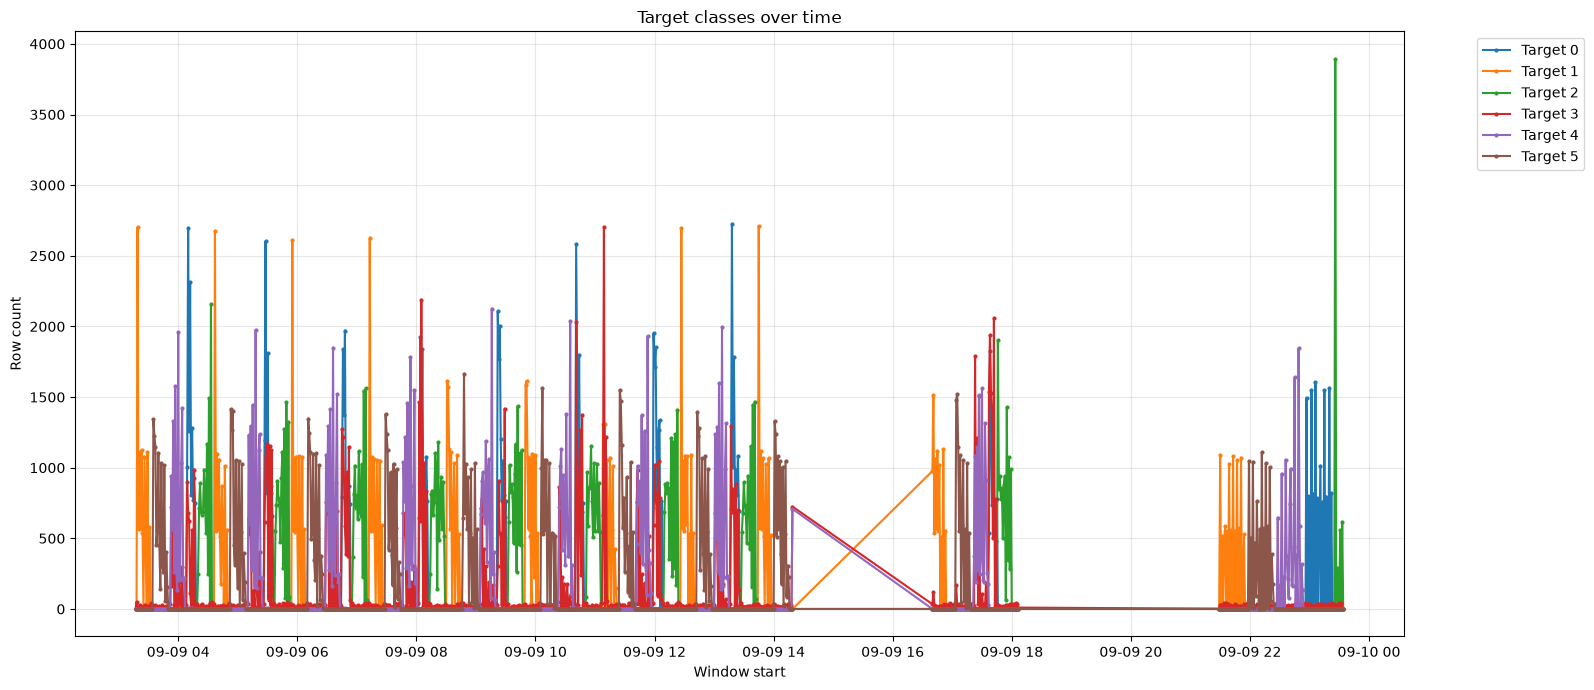


Numeric columns (12): ['tcp_flags', 'tcp_time_delta', 'tcp_len', 'mqtt_conack_flags', 'mqtt_conflag_cleansess', 'mqtt_conflags', 'mqtt_dupflag', 'mqtt_hdrflags', 'mqtt_kalive', 'mqtt_msg', 'mqtt_qos', 'Target']
Numeric summary:
                           count          mean           std           min  \
tcp_flags               634644.0  8.888574e-01      0.085166  0.000000e+00   
tcp_time_delta          634644.0  1.725879e+09  18866.222564  1.725852e+09   
tcp_len                 634644.0  4.364067e+02    529.571452  4.000000e+00   
mqtt_conack_flags       634644.0  2.312225e-01      4.300833  0.000000e+00   
mqtt_conflag_cleansess  634644.0  4.733392e-01      0.463251  0.000000e+00   
mqtt_conflags           634644.0  6.143061e+01     60.218910  0.000000e+00   
mqtt_dupflag            634644.0  0.000000e+00      0.000000  0.000000e+00   
mqtt_hdrflags           634644.0  3.420227e+01     18.371152  0.000000e+00   
mqtt_kalive             634644.0  2.829618e+01     27.789363  0.00000

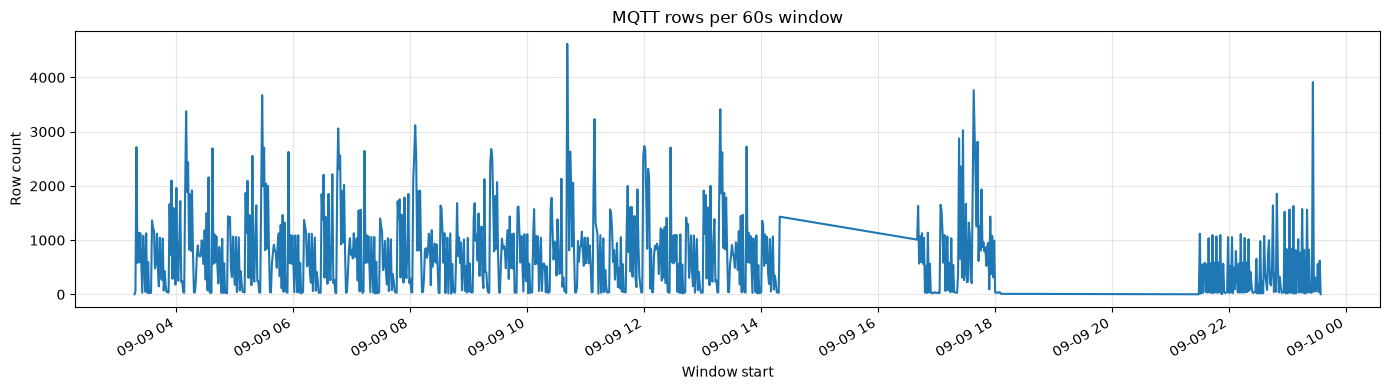


First 5 windows (start -> row count):
window_start
2024-09-09 03:17:00       1
2024-09-09 03:18:00      51
2024-09-09 03:19:00    2716
2024-09-09 03:20:00     582
2024-09-09 03:21:00    1138
dtype: int64


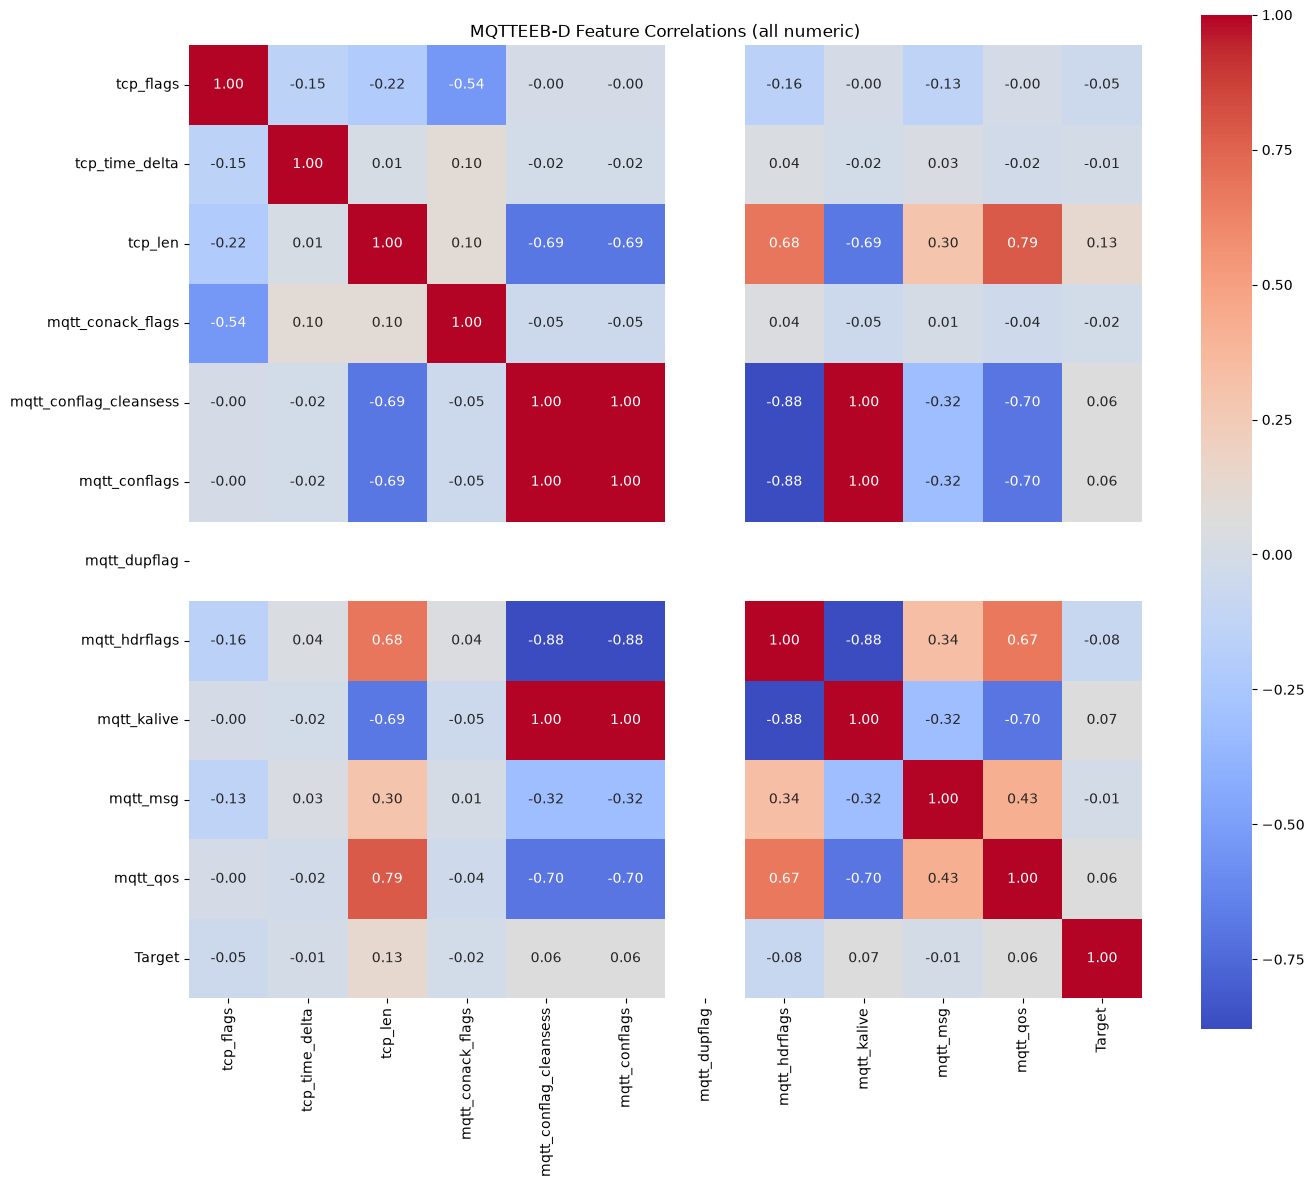


--- Target vs mqtt_qos (binned) ---
Target             0      1      2      3      4      5
mqtt_qos_bin                                           
Low           105334  49334  38636  76744  75210  69716
Mid              440  56440  67138  29027  30559  36058
High               0      0      0      3      5      0


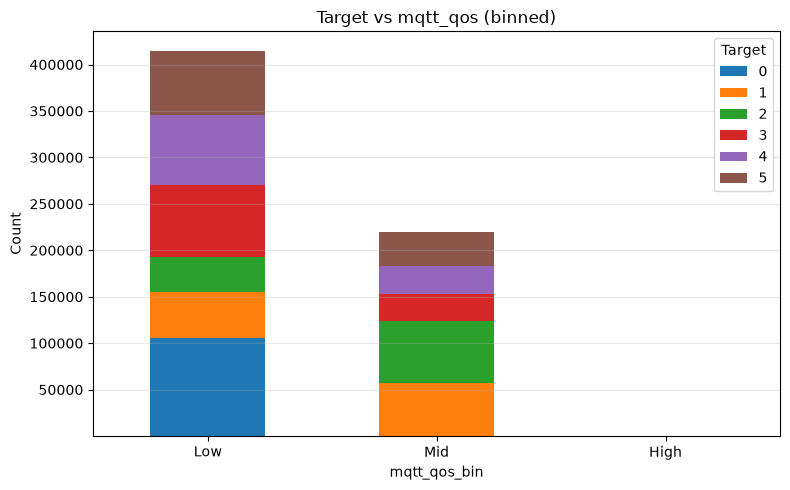


Constant columns (drop later): ['mqtt_dupflag']

Exploration complete.


In [2]:
# explore_mqtt_full.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATASET_PATH = "MQTTEEB-D_Final_Dataset/Preprocessed_Data/MQTTEEB-D_dataset_Processed_normalized.csv"
WINDOW_SECONDS = 60

df = pd.read_csv(DATASET_PATH, parse_dates=['timestamp'], low_memory=False)
print(f"Loaded {len(df)} rows, {len(df.columns)} columns.")
print("Columns:", df.columns.tolist())

print("\nSample rows:")
print(df.head())

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("\nMissing value counts:", missing if not missing.empty else "None")

# Create time windows
if 'timestamp' in df.columns:
    print(f"\nTimestamp range: {df['timestamp'].min()} to {df['timestamp'].max()}")
    df['window_start'] = df['timestamp'].dt.floor(f'{WINDOW_SECONDS}s')
    print(f"Created 'window_start' with {WINDOW_SECONDS}s bins.")

# Target distribution
if 'Target' in df.columns:
    print("\n--- Target distribution ---")
    target_counts = df['Target'].value_counts().sort_index()
    print(target_counts)
    plt.figure(figsize=(10,5))
    target_counts.plot(kind='bar', color='cornflowerblue', edgecolor='black')
    plt.title('MQTTEEB-D Target Distribution')
    plt.ylabel('Row count')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('mqtt_target.png')
    plt.show()

# Target distribution over time (stacked area + line chart)
if 'Target' in df.columns and 'window_start' in df.columns:
    target_over_time = df.groupby(['window_start', 'Target']).size().unstack(fill_value=0)
    print("\n--- Target counts per window (first 5) ---")
    print(target_over_time.head())

    # Stacked area
    plt.figure(figsize=(14,6))
    target_over_time.plot.area(stacked=True, alpha=0.7, colormap='tab10', linewidth=0.5)
    plt.title(f'Target classes per {WINDOW_SECONDS}s window (stacked area)')
    plt.xlabel('Window start')
    plt.ylabel('Row count')
    plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('mqtt_target_stacked.png')
    plt.show()

    # Line chart (all targets; if too many, show top N)
    plt.figure(figsize=(16,7))
    for col in target_over_time.columns:
        plt.plot(target_over_time.index, target_over_time[col], marker='o', markersize=2, linewidth=1.5, label=f'Target {col}')
    plt.title(f'Target classes over time')
    plt.xlabel('Window start')
    plt.ylabel('Row count')
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('mqtt_target_line.png')
    plt.show()

# Numeric summary
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")
print("Numeric summary:")
print(df[numeric_cols].describe().T[['count','mean','std','min','25%','50%','75%','max']])

# Traffic over time (rows per window)
if 'window_start' in df.columns:
    window_counts = df.groupby('window_start').size()
    plt.figure(figsize=(14,4))
    window_counts.plot(kind='line', color='tab:blue')
    plt.title(f'MQTT rows per {WINDOW_SECONDS}s window')
    plt.xlabel('Window start')
    plt.ylabel('Row count')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('mqtt_traffic.png')
    plt.show()
    print("\nFirst 5 windows (start -> row count):")
    print(window_counts.head())

# Correlation heatmap of ALL numeric features
if len(numeric_cols) > 1:
    plt.figure(figsize=(14,12))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('MQTTEEB-D Feature Correlations (all numeric)')
    plt.tight_layout()
    plt.savefig('mqtt_correlation_all.png')
    plt.show()

# Cross-tab of Target vs key numeric features (binned)
if 'Target' in df.columns:
    # Example: bin mqtt_qos into categories
    if 'mqtt_qos' in df.columns:
        df['mqtt_qos_bin'] = pd.cut(df['mqtt_qos'], bins=3, labels=['Low','Mid','High'])
        cross = pd.crosstab(df['mqtt_qos_bin'], df['Target'])
        print("\n--- Target vs mqtt_qos (binned) ---")
        print(cross)
        cross.plot(kind='bar', stacked=True, figsize=(8,5))
        plt.title('Target vs mqtt_qos (binned)')
        plt.ylabel('Count')
        plt.xticks(rotation=0)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig('mqtt_target_qos.png')
        plt.show()

# Additional: check for constant columns
constant_cols = [c for c in numeric_cols if df[c].nunique() == 1]
if constant_cols:
    print(f"\nConstant columns (drop later): {constant_cols}")

print("\nExploration complete.")

### CELL 3: NF‑ToN‑IoT‑v2 Exploration

Loaded 16940496 rows, 45 columns.
Columns: ['IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE', 'Label', 'Attack']

Sample rows:
   IPV4_SRC_ADDR  L4_SRC_PORT    IPV4_DST_ADDR  L4_DST_PORT  PROTOC

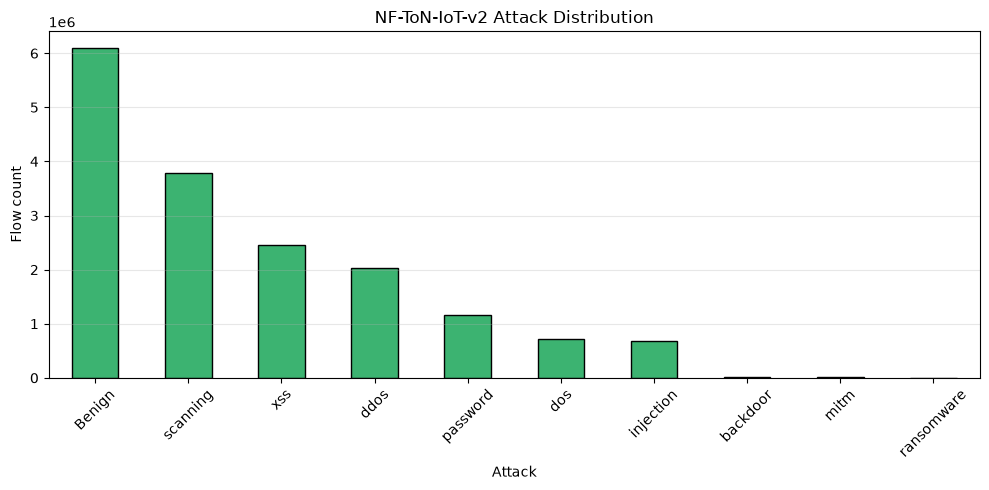


--- Label distribution ---
Label
1    10841027
0     6099469
Name: count, dtype: int64


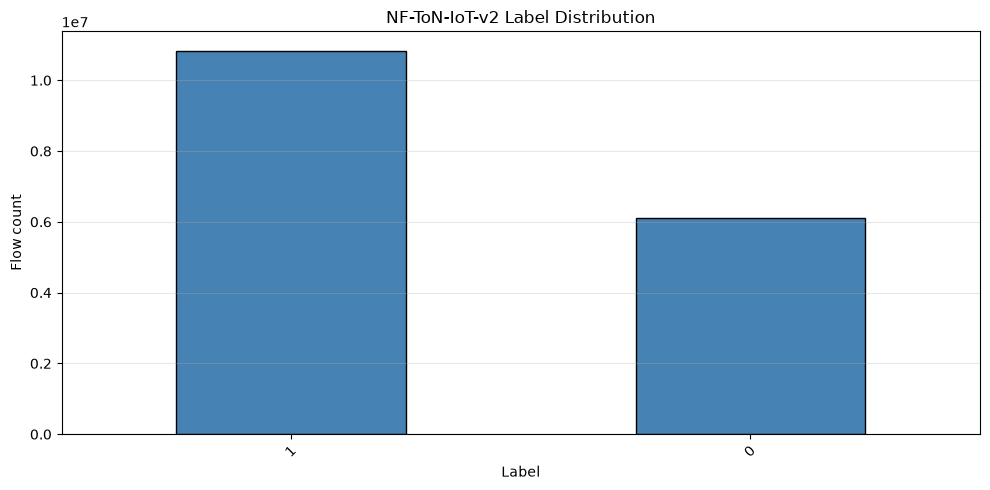


--- Attack counts per window (first 5) ---
Attack               Benign  backdoor  ddos  dos  injection  mitm  password  \
window_start                                                                  
2024-01-01 00:00:00      47         0     0    0          0     0         0   
2024-01-01 00:01:00      44         0     0    0          0     0         0   
2024-01-01 00:02:00      54         0     0    0          0     0         0   
2024-01-01 00:03:00      59         0     0    0          0     0         0   
2024-01-01 00:04:00      59         0     0    0          0     0         0   

Attack               ransomware  scanning  xss  
window_start                                    
2024-01-01 00:00:00          13         0    0  
2024-01-01 00:01:00          16         0    0  
2024-01-01 00:02:00           4         0    2  
2024-01-01 00:03:00           0         1    0  
2024-01-01 00:04:00           0         1    0  


<Figure size 1400x600 with 0 Axes>

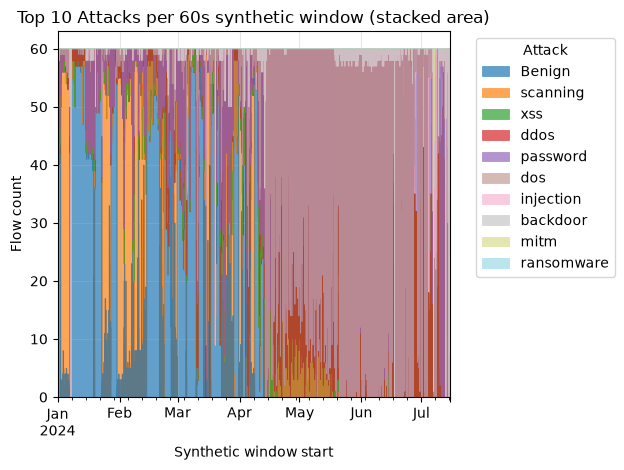

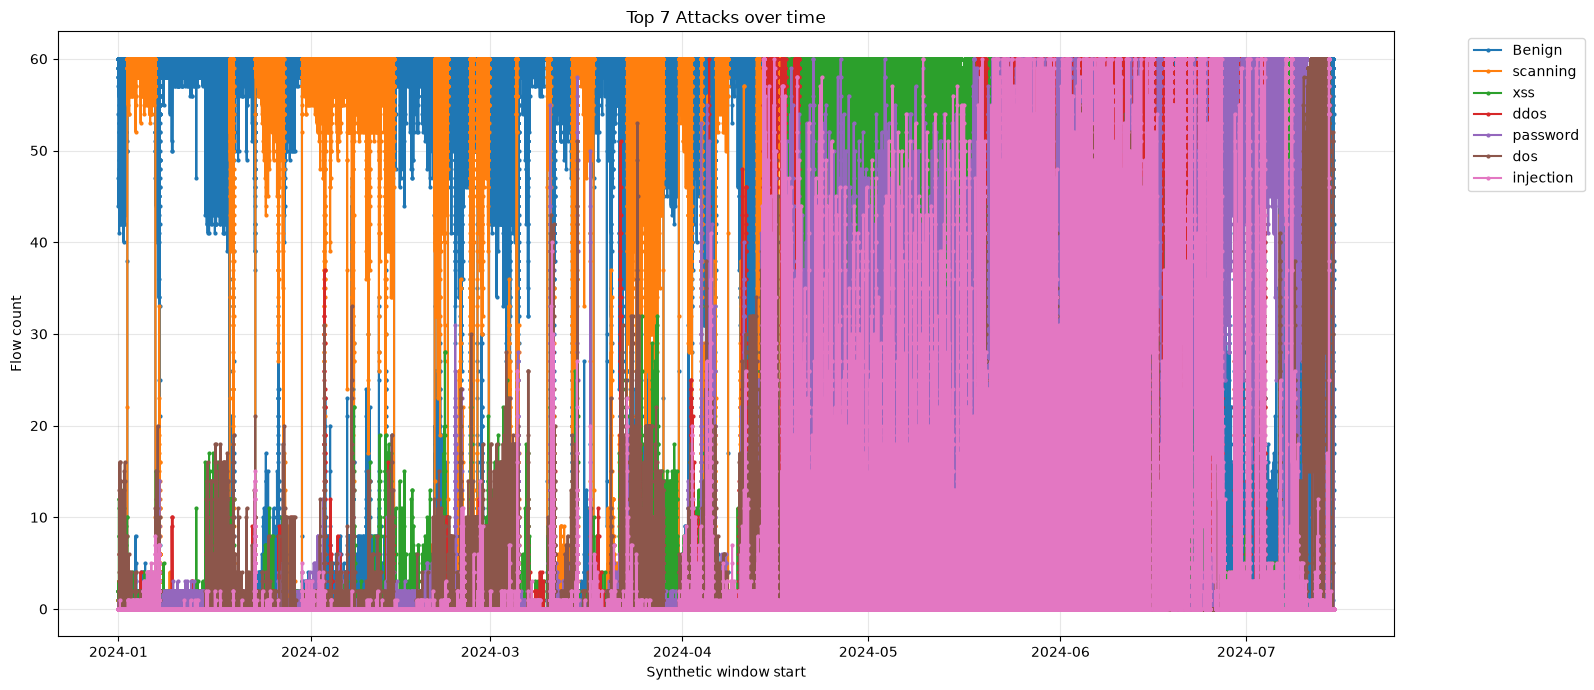


--- PROTOCOL distribution ---
PROTOCOL
6     14427073
17     2491336
1        17933
2         2912
58        1241
44           1
Name: count, dtype: int64


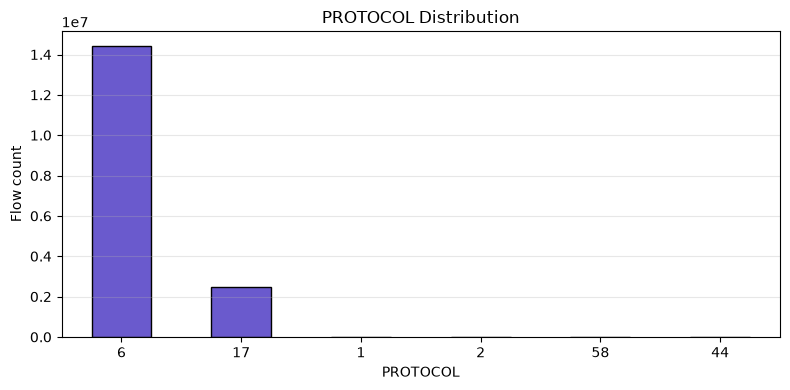


Numeric columns (42): ['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE', 'Label']
Numeric summary (first 10 columns):
                       count          mean            std  min      25%  \
L4_SRC_PORT       16940496.0  4335

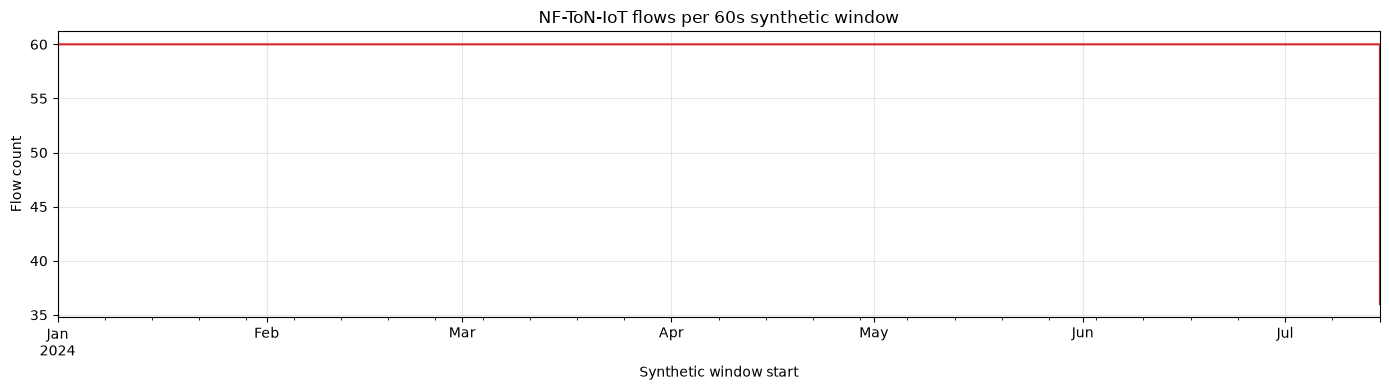

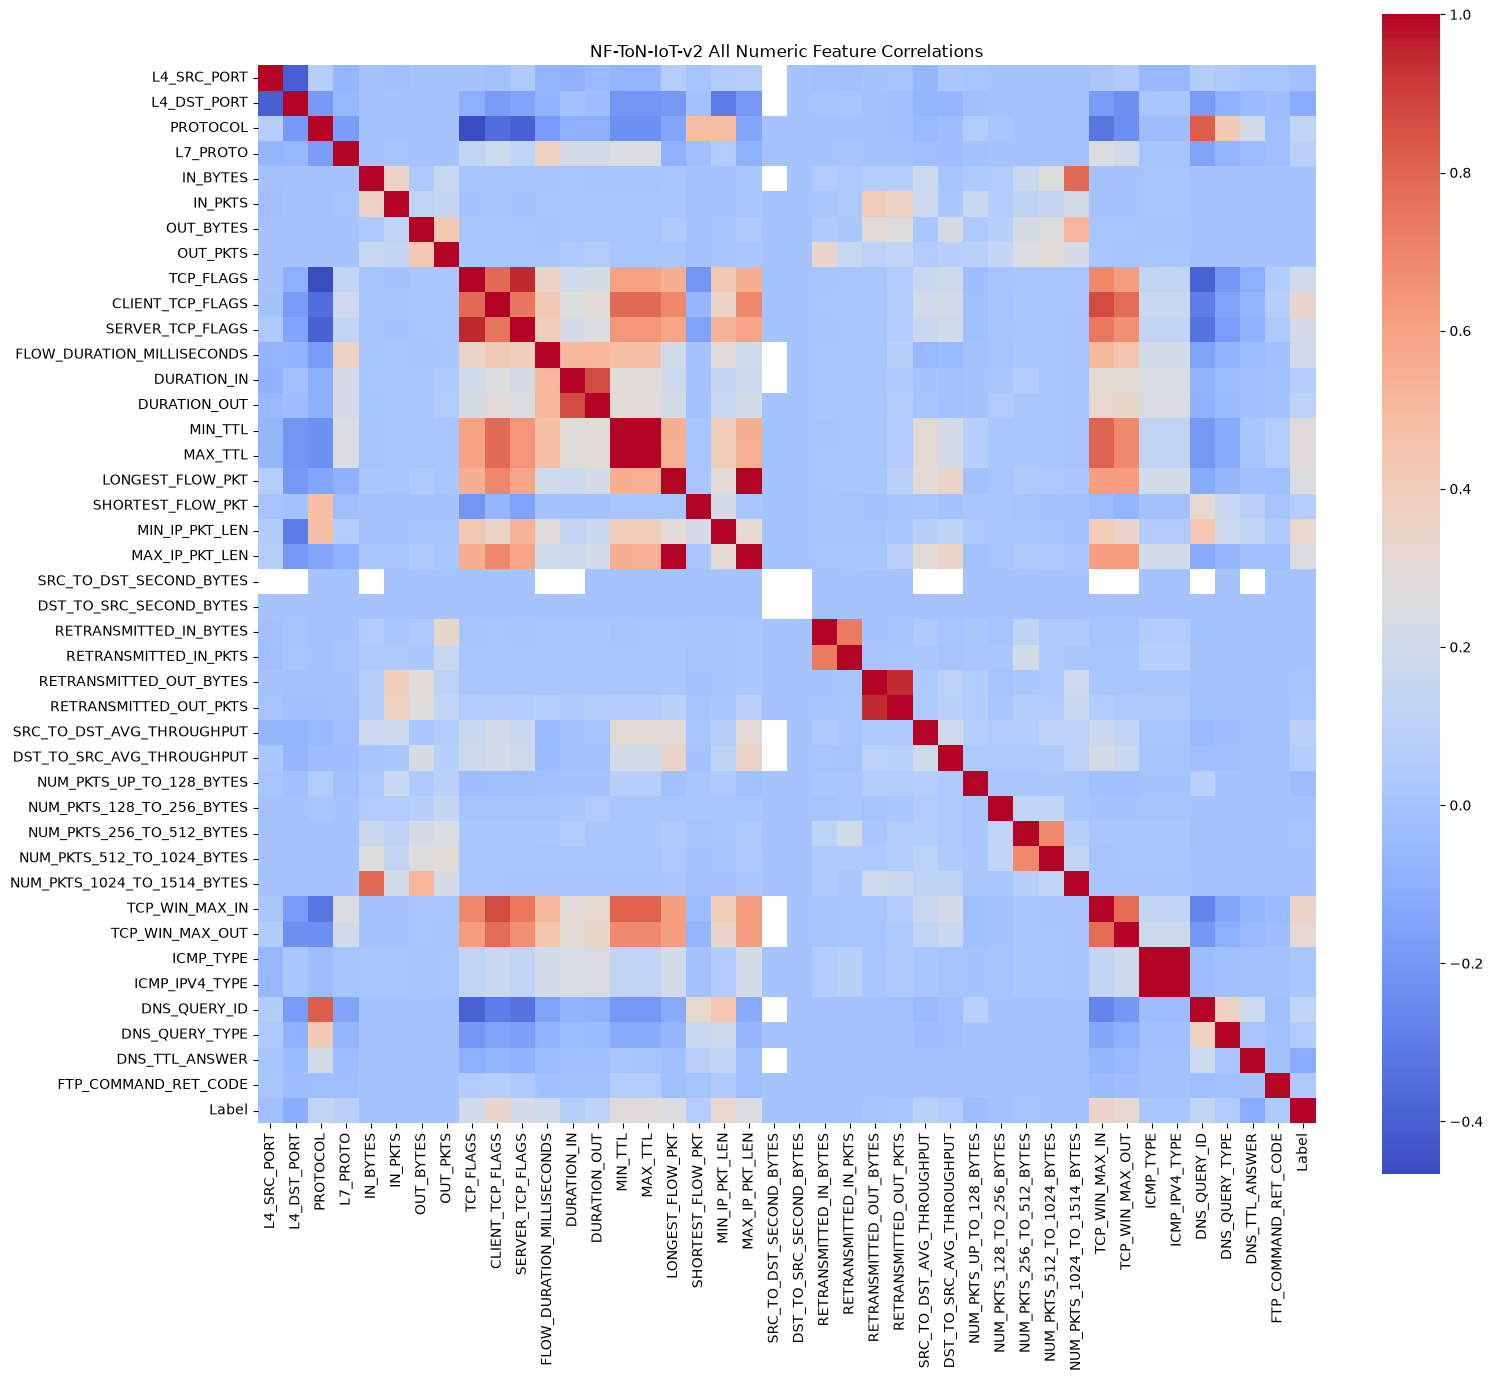


--- Attack vs PROTOCOL (top 5 protocols) ---
Attack     Benign  backdoor     ddos     dos  injection  mitm  password  \
PROTOCOL                                                                  
6         5536208     16676  1988073  103174     649311   433   1150454   
17         541174       133    38161  609435      35154  7290      2869   
1           17933         0        0       0          0     0         0   
2            2912         0        0       0          0     0         0   
58           1241         0        0       0          0     0         0   

Attack    ransomware  scanning      xss  
PROTOCOL                                 
6               3410   3775723  1203611  
17                15      5696  1251409  
1                  0         0        0  
2                  0         0        0  
58                 0         0        0  


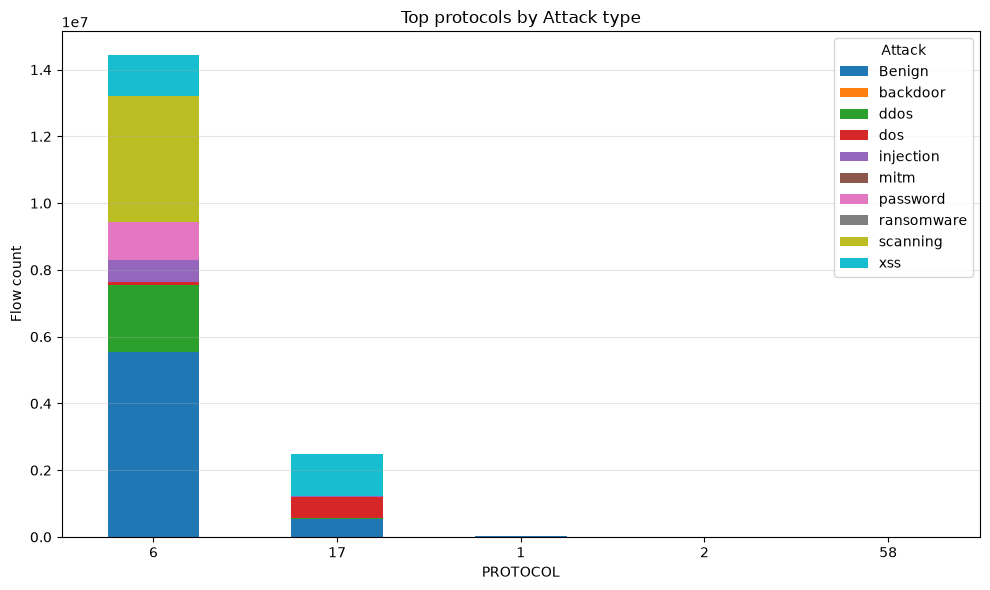


--- Label vs PROTOCOL (top 5 protocols) ---
Label           0        1
PROTOCOL                  
6         5536208  8890865
17         541174  1950162
1           17933        0
2            2912        0
58           1241        0


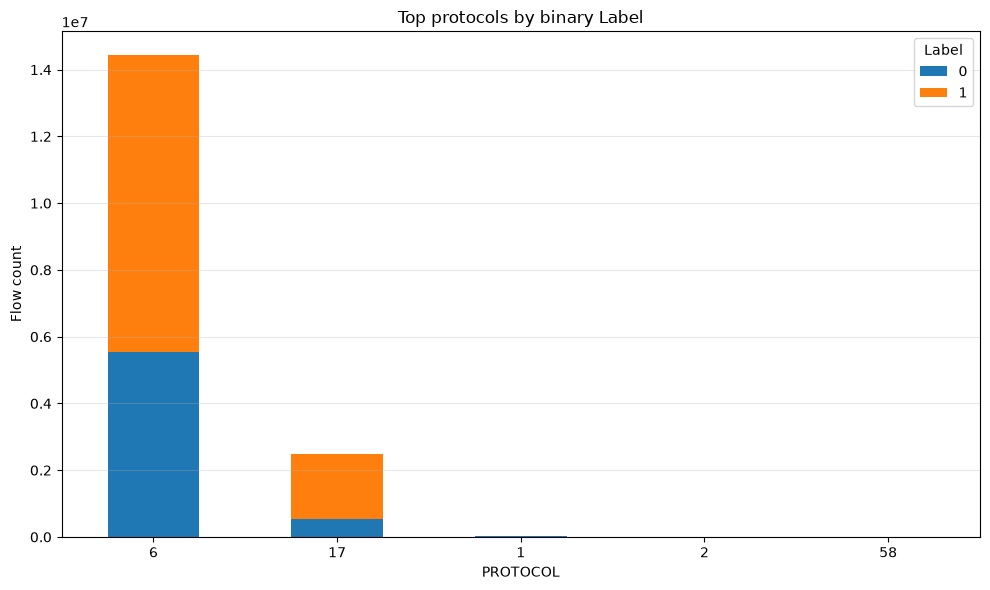


--- Network stats ---
Unique source IPs: 23079
Unique destination IPs: 6868
Unique pairs (src,dst): 31645

Flows per window (sample of 100 windows):
count    100.000000
mean      59.710000
std        0.987753
min       52.000000
25%       60.000000
50%       60.000000
75%       60.000000
max       60.000000
Name: flow_key, dtype: float64

Exploration complete.


In [3]:
# explore_flow_full.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATASET_PATH = "NF-ToN-IoT-v2/NF-ToN-IoT-v2.csv"
WINDOW_SECONDS = 60   # synthetic windows based on row order

df = pd.read_csv(DATASET_PATH, low_memory=False)
print(f"Loaded {len(df)} rows, {len(df.columns)} columns.")
print("Columns:", df.columns.tolist())

print("\nSample rows:")
print(df.head())

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("\nMissing value counts:", missing if not missing.empty else "None")

# Create synthetic timestamp (since no real time)
df['synthetic_time'] = pd.to_datetime('2024-01-01') + pd.to_timedelta(df.index, unit='s')
df['window_start'] = df['synthetic_time'].dt.floor(f'{WINDOW_SECONDS}s')
print(f"\nCreated synthetic 'window_start' with {WINDOW_SECONDS}s bins (based on row order).")

# Label distributions (Attack and binary Label)
for col in ['Attack', 'Label']:
    if col in df.columns:
        print(f"\n--- {col} distribution ---")
        counts = df[col].value_counts(dropna=False)
        print(counts)
        plt.figure(figsize=(10,5))
        counts.plot(kind='bar', color='mediumseagreen' if col=='Attack' else 'steelblue', edgecolor='black')
        plt.title(f'NF-ToN-IoT-v2 {col} Distribution')
        plt.ylabel('Flow count')
        plt.xticks(rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'flow_{col}.png')
        plt.show()

# Attack distribution over synthetic time (stacked area + line)
if 'Attack' in df.columns and 'window_start' in df.columns:
    attack_over_time = df.groupby(['window_start', 'Attack']).size().unstack(fill_value=0)
    print("\n--- Attack counts per window (first 5) ---")
    print(attack_over_time.head())

    # Stacked area (use top 10 attack types)
    top_attacks = attack_over_time.sum().sort_values(ascending=False).head(10).index
    attack_top = attack_over_time[top_attacks]
    plt.figure(figsize=(14,6))
    attack_top.plot.area(stacked=True, alpha=0.7, colormap='tab20', linewidth=0.5)
    plt.title(f'Top 10 Attacks per {WINDOW_SECONDS}s synthetic window (stacked area)')
    plt.xlabel('Synthetic window start')
    plt.ylabel('Flow count')
    plt.legend(title='Attack', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('flow_attacks_stacked.png')
    plt.show()

    # Line chart (top 7)
    top_7 = attack_top.columns[:7]
    plt.figure(figsize=(16,7))
    for col in top_7:
        plt.plot(attack_top.index, attack_top[col], marker='o', markersize=2, linewidth=1.5, label=col)
    plt.title(f'Top 7 Attacks over time')
    plt.xlabel('Synthetic window start')
    plt.ylabel('Flow count')
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('flow_attacks_line.png')
    plt.show()

# Protocol distribution
if 'PROTOCOL' in df.columns:
    proto_counts = df['PROTOCOL'].value_counts()
    print("\n--- PROTOCOL distribution ---")
    print(proto_counts)
    plt.figure(figsize=(8,4))
    proto_counts.plot(kind='bar', color='slateblue', edgecolor='black')
    plt.title('PROTOCOL Distribution')
    plt.ylabel('Flow count')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('flow_protocols.png')
    plt.show()

# Numeric summary (all numeric columns)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")
print("Numeric summary (first 10 columns):")
print(df[numeric_cols].describe().T[['count','mean','std','min','25%','50%','75%','max']].head(10))
# For all columns, you can uncomment:
# print(df[numeric_cols].describe().T)

# Traffic over time (synthetic windows)
if 'window_start' in df.columns:
    window_counts = df.groupby('window_start').size()
    plt.figure(figsize=(14,4))
    window_counts.plot(kind='line', color='tab:red')
    plt.title(f'NF-ToN-IoT flows per {WINDOW_SECONDS}s synthetic window')
    plt.xlabel('Synthetic window start')
    plt.ylabel('Flow count')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('flow_traffic.png')
    plt.show()

# Correlation heatmap of ALL numeric columns (but too many may slow; we'll sample)
# We'll take a subset of important numeric features (or all if not too many)
if len(numeric_cols) <= 50:
    plt.figure(figsize=(16,14))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=False, cmap='coolwarm', square=True)
    plt.title('NF-ToN-IoT-v2 All Numeric Feature Correlations')
    plt.tight_layout()
    plt.savefig('flow_correlation_all.png')
    plt.show()
else:
    # Select a meaningful subset
    selected = ['IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS',
                'FLOW_DURATION_MILLISECONDS', 'TCP_FLAGS', 'MIN_TTL', 'MAX_TTL',
                'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
                'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
                'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
                'NUM_PKTS_1024_TO_1514_BYTES']
    selected = [c for c in selected if c in df.columns]
    plt.figure(figsize=(14,12))
    corr = df[selected].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('NF-ToN-IoT-v2 Selected Feature Correlations')
    plt.tight_layout()
    plt.savefig('flow_correlation_selected.png')
    plt.show()

# Cross-tab of Attack vs PROTOCOL (top protocols)
if 'Attack' in df.columns and 'PROTOCOL' in df.columns:
    print("\n--- Attack vs PROTOCOL (top 5 protocols) ---")
    top_protos = df['PROTOCOL'].value_counts().head(5).index
    prot_attack = pd.crosstab(df['PROTOCOL'], df['Attack'])
    print(prot_attack.loc[top_protos])
    prot_attack.loc[top_protos].plot(kind='bar', stacked=True, figsize=(10,6))
    plt.title('Top protocols by Attack type')
    plt.ylabel('Flow count')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('flow_protocol_attack.png')
    plt.show()

# Cross-tab of Label vs PROTOCOL (optional)
if 'Label' in df.columns and 'PROTOCOL' in df.columns:
    print("\n--- Label vs PROTOCOL (top 5 protocols) ---")
    top_protos = df['PROTOCOL'].value_counts().head(5).index
    prot_label = pd.crosstab(df['PROTOCOL'], df['Label'])
    print(prot_label.loc[top_protos])
    prot_label.loc[top_protos].plot(kind='bar', stacked=True, figsize=(10,6))
    plt.title('Top protocols by binary Label')
    plt.ylabel('Flow count')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('flow_protocol_label.png')
    plt.show()

# Additional network stats
if 'IPV4_SRC_ADDR' in df.columns and 'IPV4_DST_ADDR' in df.columns:
    print("\n--- Network stats ---")
    print(f"Unique source IPs: {df['IPV4_SRC_ADDR'].nunique()}")
    print(f"Unique destination IPs: {df['IPV4_DST_ADDR'].nunique()}")
    print(f"Unique pairs (src,dst): {df.groupby(['IPV4_SRC_ADDR','IPV4_DST_ADDR']).ngroups}")

# Flows per window (sample 100 windows)
if 'window_start' in df.columns:
    sample_windows = df['window_start'].value_counts().head(100).index
    df_sample = df[df['window_start'].isin(sample_windows)]
    def get_flow_key(row):
        return (row['IPV4_SRC_ADDR'], row['IPV4_DST_ADDR'], row['PROTOCOL'],
                row['L4_SRC_PORT'], row['L4_DST_PORT'])
    df_sample['flow_key'] = df_sample.apply(get_flow_key, axis=1)
    flows_per_window = df_sample.groupby('window_start')['flow_key'].nunique()
    print("\nFlows per window (sample of 100 windows):")
    print(flows_per_window.describe())

print("\nExploration complete.")